# End-to-End Pipeline: Source Training, Safety Shielding, Rashomon Sets, and Downstream Adaptation

This notebook walks through the full certified-continual-learning pipeline on a small
FrozenLake gridworld:

1. Train a PPO policy on a **source** task.
2. Build a **safety shield** over the gridworld (which actions avoid holes) and turn it
   into a Rashomon-set training dataset.
3. Supervised-finetune the policy so it always picks a shielded (safe) action.
4. Compute a **Rashomon set** — a certified box of parameters that all keep 100% of
   safety-critical states safe — using the new `compute_rashomon_set` / `AccuracyRequirement` API.
5. Adapt the policy to a **downstream** task (a different map), comparing an
   unconstrained PPO fine-tune against one constrained to stay inside the certified box.

**Reference pipeline.** This follows the structure of
`experiments/pipelines/frozenlake_safety/core/{pipeline,safety,env,models,config}.py`
(note: the directory the task may be remembered by, `frozenlake_shield_safety`, no
longer has any source files — it was superseded by `frozenlake_safety` in a later
refactor; that's the live, tested pipeline this notebook draws from).

**On "shielding."** The safety shield here is a simple, deterministic, hand-written
rule (`safe_action_mask_for_state`): an action is unsafe if it steps into a hole `H`.
This is what the current pipeline actually computes — it is not a synthesized
probabilistic shield (the kind a tool like `masa` would produce); this notebook just
hand-codes the one-step lookahead rule directly.

**Scale.** Hyperparameters below match the pipeline's `diagonal_4x4` settings
(`experiments/pipelines/frozenlake_safety/settings/`), except the Rashomon optimizer's
`n_iters`, which is reduced from the production value of 20000 to 2000 so the notebook
runs in well under a minute. Bump it back up for a tighter/larger certified box.

In [1]:
import copy
import sys
from pathlib import Path

import torch

def find_repo_root(start: Path) -> Path:
    for path in [start, *start.parents]:
        if (path / ".git").exists():
            return path
    raise FileNotFoundError("Could not locate repo root containing .git")

REPO_ROOT = find_repo_root(Path.cwd())
for p in (REPO_ROOT, REPO_ROOT / "core"):
    if str(p) not in sys.path:
        sys.path.insert(0, str(p))

SEED = 0
DEVICE = "cpu"
torch.manual_seed(SEED)

## 1. The task: source and downstream layouts

`PipelineConfig` (loaded from the pipeline's settings YAML) defines a 4x4 source map and
a 4x4 downstream map with holes (`H`) in different places, plus all PPO/Rashomon
hyperparameters tuned for this layout. `S`=start, `F`=frozen (safe), `H`=hole (unsafe),
`G`=goal.

In [2]:
from experiments.pipelines.frozenlake_safety.core.config import get_pipeline_config, OBS_DIM

cfg = get_pipeline_config("diagonal_4x4")

print("Source map:")
for row in cfg.source_map:
    print(" ", row)
print("\nDownstream map:")
for row in cfg.downstream_map:
    print(" ", row)
print(f"\nhidden={cfg.hidden} activation={cfg.activation} obs_dim={OBS_DIM}")

Source map:
  SFHH
  FFFH
  HFFF
  HFFG

Downstream map:
  SFFH
  FHFH
  FFFF
  HFFG

hidden=128 activation=relu obs_dim=3


## 2. Train a source PPO policy

Training uses dense reward shaping (`shaped=True`); early stopping and the rollout we
inspect below use the sparse, true environment reward (`shaped=False`).

In [3]:
from experiments.pipelines.frozenlake_safety.core.env import make_env
from experiments.pipelines.frozenlake_safety.core.models import build_actor_critic
from experiments.utils.ppo_utils import PPOConfig, ppo_train

actor, critic = build_actor_critic(obs_dim=OBS_DIM, hidden=cfg.hidden, activation=cfg.activation)

source_ppo_cfg = PPOConfig(
    seed=SEED,
    total_timesteps=cfg.source_total_timesteps,
    eval_episodes=cfg.eval_episodes,
    rollout_steps=cfg.source_rollout_steps,
    update_epochs=cfg.source_update_epochs,
    minibatch_size=cfg.source_minibatch_size,
    gamma=cfg.source_gamma,
    gae_lambda=cfg.source_gae_lambda,
    clip_coef=cfg.source_clip_coef,
    ent_coef=cfg.source_ent_coef,
    vf_coef=cfg.source_vf_coef,
    lr=cfg.source_lr,
    max_grad_norm=cfg.source_max_grad_norm,
    device=DEVICE,
    early_stop_reward_threshold=cfg.source_early_stop_reward_threshold,
    early_stop_failure_rate_threshold=cfg.source_early_stop_failure_rate_threshold,
)

source_train_env = make_env(cfg.source_map, task_num=cfg.source_task_num, max_episode_steps=cfg.max_episode_steps, shaped=True)
source_eval_env = make_env(cfg.source_map, task_num=cfg.source_task_num, max_episode_steps=cfg.max_episode_steps, shaped=False)

actor, critic, source_training_data = ppo_train(
    source_train_env,
    source_ppo_cfg,
    actor_warm_start=actor,
    critic_warm_start=critic,
    early_stop_eval_env=source_eval_env,
    return_training_data=True,
)
source_train_env.close()
source_eval_env.close()
actor.cpu()
critic.cpu()

I0000 00:00:1782044855.216569 2215338 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1782044855.290668 2215338 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1782044934.359124 2215338 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


Use PGD: False
Pre-update check | Steps=0 | meanR=0.0 +/- 0.0 | failure_rate=1.00 | success_rate=0.00
Steps=10240 | meanR=0.0 +/- 0.0 | elapsed=6.4s | failure_rate=1.00 | success_rate=0.00
Steps=20480 | meanR=1.0 +/- 0.0 | elapsed=13.0s | failure_rate=0.00 | success_rate=1.00
  [Early stop] updates=20 | step=20480 | meanR=1.00 (threshold=1.0) | failure_rate=0.00 (threshold=0.0) | success_rate=1.00 (threshold=None)
Final evaluation over 1 episodes: mean_reward=1.00 +/- 0.00 | failure_rate=0.00 | success_rate=1.00


Sequential(
  (0): Linear(in_features=3, out_features=128, bias=True)
  (1): ReLU()
  (2): Linear(in_features=128, out_features=128, bias=True)
  (3): ReLU()
  (4): Linear(in_features=128, out_features=1, bias=True)
)

In [4]:
from experiments.pipelines.frozenlake_safety.core.safety import rollout_greedy_policy

source_rollout_env = make_env(cfg.source_map, task_num=cfg.source_task_num, max_episode_steps=cfg.max_episode_steps, shaped=False)
source_rollout = rollout_greedy_policy(actor, source_rollout_env, seed=SEED, device=DEVICE)
source_rollout_env.close()

print(f"Greedy source rollout: total_reward={source_rollout.total_reward:.2f} failure_rate={source_rollout.failure_rate:.2f}")
assert source_rollout.total_reward >= 1.0 and source_rollout.failure_rate == 0.0, "Source policy should solve its task safely before we shield it."


Greedy source rollout: total_reward=1.00 failure_rate=0.00


ALSA lib confmisc.c:855:(parse_card) cannot find card '0'
ALSA lib conf.c:5178:(_snd_config_evaluate) function snd_func_card_inum returned error: No such file or directory
ALSA lib confmisc.c:422:(snd_func_concat) error evaluating strings
ALSA lib conf.c:5178:(_snd_config_evaluate) function snd_func_concat returned error: No such file or directory
ALSA lib confmisc.c:1334:(snd_func_refer) error evaluating name
ALSA lib conf.c:5178:(_snd_config_evaluate) function snd_func_refer returned error: No such file or directory
ALSA lib conf.c:5701:(snd_config_expand) Evaluate error: No such file or directory
ALSA lib pcm.c:2664:(snd_pcm_open_noupdate) Unknown PCM default


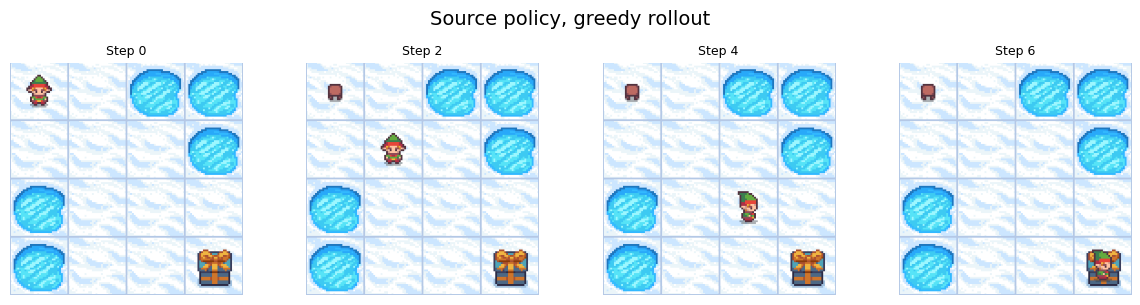

In [5]:
from experiments.utils.gymnasium_utils import plot_episode

render_env = make_env(cfg.source_map, task_num=cfg.source_task_num, max_episode_steps=cfg.max_episode_steps, shaped=False, render_mode="rgb_array")
_ = plot_episode(actor.cpu(), env=render_env, seed=SEED, deterministic=True, one_row=True, title="Source policy, greedy rollout")
render_env.close()

## 3. Shielding: a safety mask over states

`safe_action_mask_for_state` is the shield: for every traversable, non-terminal state it
returns a multi-hot mask over the 4 actions, marking an action unsafe if it steps into a
hole. `create_rashomon_dataset` enumerates every such state on the source map and
attaches its safety mask — this *is* the safety demonstration dataset that
`compute_rashomon_set` will certify against.

In [6]:
from experiments.pipelines.frozenlake_safety.core.safety import (
    create_rashomon_dataset,
    safe_action_mask_for_state,
    traversable_nonterminal_states,
)

rashomon_payload = create_rashomon_dataset(cfg.source_map, task_num=cfg.source_task_num)
print(f"Shield dataset: {rashomon_payload['state'].shape[0]} states, action-mask shape {tuple(rashomon_payload['actions'].shape)}")

ACTION_NAMES = {0: "left", 1: "down", 2: "right", 3: "up"}
critical_states = [
    s for s in traversable_nonterminal_states(cfg.source_map)
    if safe_action_mask_for_state(cfg.source_map, s).sum() < 4
]
print(f"\n{len(critical_states)} safety-critical states (at least one unsafe action):")
for s in critical_states:
    mask = safe_action_mask_for_state(cfg.source_map, s)
    row, col = divmod(s, len(cfg.source_map[0]))
    safe_actions = [ACTION_NAMES[a] for a in range(4) if mask[a] > 0]
    print(f"  state {s:2d} (row={row}, col={col}): safe actions = {safe_actions}")

Shield dataset: 10 states, action-mask shape (10, 4)

6 safety-critical states (at least one unsafe action):
  state  1 (row=0, col=1): safe actions = ['left', 'down', 'up']
  state  4 (row=1, col=0): safe actions = ['left', 'right', 'up']
  state  6 (row=1, col=2): safe actions = ['left', 'down']
  state  9 (row=2, col=1): safe actions = ['down', 'right', 'up']
  state 11 (row=2, col=3): safe actions = ['left', 'down', 'right']
  state 13 (row=3, col=1): safe actions = ['down', 'right', 'up']


## 4. Supervised safety fine-tuning

Even though the rollout above is already safe, the policy's behaviour off-trajectory is
unconstrained — `argmax` could land on an unsafe action in a safety-critical state it
never visited during training. `build_noadapt_supervised_payload` keeps the shield mask
everywhere except the source trajectory's own states, where it pins the single action
the policy actually took (so fine-tuning can't quietly change the trajectory it already
solved). `finetune_on_allowed_actions` then pushes `argmax` into the allowed set
everywhere via a masked-softmax loss.

In [7]:
from experiments.pipelines.frozenlake_safety.core.safety import (
    allowed_action_accuracy,
    build_noadapt_supervised_payload,
    finetune_on_allowed_actions,
)

supervised_payload = build_noadapt_supervised_payload(
    rashomon_payload,
    env_map=cfg.source_map,
    trajectory_steps=source_rollout.steps,
)

pre_finetune_acc = allowed_action_accuracy(actor, supervised_payload, device=DEVICE)
print(f"Allowed-action accuracy before fine-tuning: {pre_finetune_acc:.3f}")

finetune_result = finetune_on_allowed_actions(
    actor,
    supervised_payload,
    trajectory_steps=source_rollout.steps,
    env_map=cfg.source_map,
    task_num=cfg.source_task_num,
    lr=cfg.safety_finetune_lr,
    max_epochs=cfg.safety_finetune_max_epochs,
    seed=SEED,
    device=DEVICE,
    verbose=False,
)
print(f"Fine-tune result: {finetune_result}")
assert finetune_result["reached_target"], "Safety fine-tuning should reach 100% allowed-action accuracy."


Allowed-action accuracy before fine-tuning: 1.000
Fine-tune result: {'epochs_run': 0, 'initial_accuracy': 1.0, 'final_accuracy': 1.0, 'trajectory_preserved': True, 'reached_target': True}


## 5. Computing the Rashomon set (new API)

This is the part the new API simplifies. Instead of separately specifying a soft
threshold, a hard threshold, a softmax temperature, and an aggregation rule, we give
`AccuracyRequirement` a single number — `target_accuracy=1.0`, meaning "every
safety-critical state must be certified safe" — and the differentiable surrogate, its
exact order-statistic aggregation, and the softmax temperature are all calibrated
automatically.

`IntervalTrainer` is a thin wrapper around `src.interval_utils.compute_rashomon_set`
that also tracks per-checkpoint bounded models — we use it here so the call mirrors how
the actual pipeline (`core/pipeline.py::_compute_rashomon_bounds`) invokes it, modulo the
field rename (the pipeline's checked-in code still uses the old
`soft_min`/`hard_min`/`soft_temperature` fields, which `AccuracyRequirement` no longer
has — that call site predates this API change and would need updating to look like the
cell below).

In [8]:
from src.rashomon_spec import AccuracyRequirement
from src.trainer.IntervalTrainer import IntervalTrainer
from experiments.pipelines.frozenlake_safety.core.safety import to_tensor_dataset

rashomon_dataset = to_tensor_dataset(rashomon_payload)

interval_trainer = IntervalTrainer(
    model=copy.deepcopy(actor).cpu(),
    accuracy=AccuracyRequirement(target_accuracy=1.0),
    min_acc_increment=0,   # don't relax the target based on current task accuracy
    seed=SEED,
    n_iters=2000,          # production setting (rashomon.yaml) uses 20000
    checkpoint=100,
)
interval_trainer.compute_rashomon_set(dataset=rashomon_dataset, multi_label=True)

Calibrated temperatures: {None: 0.1}
Initial acc constraint violation (group=None): -0.2000 (Positive = violated)
Number of model parameters: 17540
Computing Rashomon set with target accuracies: {None: 1.0}
Initial bbox:  Obj=0.00,  Size=0.00,  Certificates=[RashomonCertificate(group=None, min_soft_acc=0.19999998807907104, min_hard_acc=1.0)]


100%|██████████| 2000/2000 [00:23<00:00, 86.02it/s, size=4534.90, obj=0.258, min_soft_acc=-0.010]


Final bbox:  Obj=0.26,  Size=4534.90,  Certificates=[RashomonCertificate(group=None, min_soft_acc=-0.0024547576904296875, min_hard_acc=1.0)]
Computing final certificates over 256 samples using IBP
Num cert samples: 10
Checkpointed every 100 iterations for a total of 20 checkpoints
Checkpoints sizes: ['239.62', '499.66', '741.15', '967.73', '1192.39', '1415.37', '1638.99', '1862.44', '2085.73', '2309.82', '2532.74', '2756.27', '2979.12', '3202.47', '3425.15', '3647.67', '3869.00', '4091.49', '4313.24', '4534.90']
Checkpoint certificates: [[RashomonCertificate(group=None, min_soft_acc=0.17422908544540405, min_hard_acc=1.0)], [RashomonCertificate(group=None, min_soft_acc=-0.0010079741477966309, min_hard_acc=1.0)], [RashomonCertificate(group=None, min_soft_acc=0.09070396423339844, min_hard_acc=1.0)], [RashomonCertificate(group=None, min_soft_acc=-7.647275924682617e-05, min_hard_acc=1.0)], [RashomonCertificate(group=None, min_soft_acc=-4.965066909790039e-05, min_hard_acc=1.0)], [RashomonCer

In [9]:
cert_values = [
    min((c.min_hard_acc for c in certs), default=float("-inf"))
    for certs in interval_trainer.certificates
]
valid_indices = [i for i, v in enumerate(cert_values) if v >= 1.0]
if not valid_indices:
    raise ValueError(f"No Rashomon checkpoint reached 100% certified safety; certificates={cert_values}")

print(f"{len(valid_indices)}/{len(cert_values)} checkpoints are fully certified (hard_acc >= 1.0).")

# Take the last fully-certified checkpoint: the largest box that's still fully safe.
selected_idx = valid_indices[-1]
bounded_model = interval_trainer.bounds[selected_idx]
param_bounds_l = [p.detach().cpu() for p in bounded_model.param_l]
param_bounds_u = [p.detach().cpu() for p in bounded_model.param_u]
print(f"Selected checkpoint {selected_idx}, calibrated temperature tau={interval_trainer.temperatures}")

20/20 checkpoints are fully certified (hard_acc >= 1.0).
Selected checkpoint 19, calibrated temperature tau={None: 0.1}


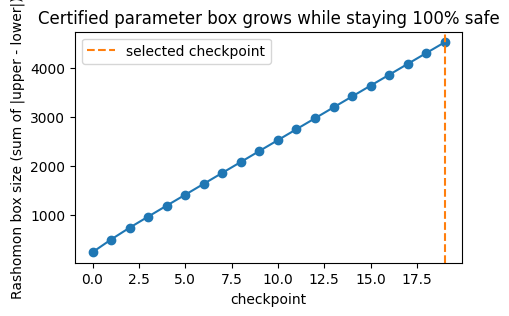

In [10]:
import matplotlib.pyplot as plt

box_sizes = [
    sum((u - l).abs().sum().item() for l, u in zip(bm.param_l, bm.param_u))
    for bm in interval_trainer.bounds
]
fig, ax = plt.subplots(figsize=(5, 3))
ax.plot(box_sizes, marker="o")
ax.axvline(selected_idx, color="tab:orange", linestyle="--", label="selected checkpoint")
ax.set_xlabel("checkpoint")
ax.set_ylabel("Rashomon box size (sum of |upper - lower|)")
ax.set_title("Certified parameter box grows while staying 100% safe")
ax.legend()
plt.show()

In [11]:
from src.utils.general import sort_parameter_bounds_by_width
import pandas as pd

widest = sort_parameter_bounds_by_width(param_bounds_l, param_bounds_u)[:10]
pd.DataFrame(widest).round(3)

,tensor_index,flat_index,width
0,2,2368,0.451
1,2,10048,0.451
2,2,13730,0.451
3,2,4794,0.451
4,2,14778,0.451
5,2,7842,0.451
6,2,4002,0.451
7,2,6586,0.451
8,2,15010,0.451
9,2,7330,0.451


## 6. Adapting to a downstream task

The downstream task is a *different* map (`cfg.downstream_map`) with `task_num=1.0`
instead of `0.0` so the network can tell the tasks apart. We warm-start PPO from the
source actor/critic in both cases; the only difference is whether the actor's
parameters are kept inside the certified Rashomon box (`actor_param_bounds_l/u`, applied
via projected gradient descent inside `ppo_train`) while it adapts.

A note on what to expect from the comparison in §7: on this small gridworld the
unconstrained fine-tune often *doesn't* visibly forget the source safety property
either — see §7 for why that doesn't make the certified Rashomon box redundant.

In [12]:
downstream_ppo_cfg = PPOConfig(
    seed=SEED,
    total_timesteps=cfg.downstream_total_timesteps,
    eval_episodes=cfg.eval_episodes,
    rollout_steps=cfg.downstream_rollout_steps,
    update_epochs=cfg.downstream_update_epochs,
    minibatch_size=cfg.downstream_minibatch_size,
    gamma=cfg.downstream_gamma,
    gae_lambda=cfg.downstream_gae_lambda,
    clip_coef=cfg.downstream_clip_coef,
    ent_coef=cfg.downstream_ent_coef,
    vf_coef=cfg.downstream_vf_coef,
    lr=cfg.downstream_lr,
    max_grad_norm=cfg.downstream_max_grad_norm,
    device=DEVICE,
    early_stop_reward_threshold=cfg.downstream_early_stop_reward_threshold,
)

downstream_train_env = make_env(cfg.downstream_map, task_num=cfg.downstream_task_num, max_episode_steps=cfg.max_episode_steps, shaped=True)
downstream_eval_env = make_env(cfg.downstream_map, task_num=cfg.downstream_task_num, max_episode_steps=cfg.max_episode_steps, shaped=False)

print("Adapting without constraints...")
unconstrained_actor, unconstrained_critic, _ = ppo_train(
    downstream_train_env,
    downstream_ppo_cfg,
    actor_warm_start=copy.deepcopy(actor),
    critic_warm_start=copy.deepcopy(critic),
    early_stop_eval_env=downstream_eval_env,
    return_training_data=True,
)
unconstrained_actor.cpu()

Adapting without constraints...
Use PGD: False
Pre-update check | Steps=0 | meanR=0.0 +/- 0.0 | failure_rate=1.00 | success_rate=0.00
Steps=10240 | meanR=1.0 +/- 0.0 | elapsed=7.2s | failure_rate=0.00 | success_rate=1.00
  [Early stop] updates=10 | step=10240 | meanR=1.00 (threshold=1.0) | failure_rate=0.00 (threshold=None) | success_rate=1.00 (threshold=None)
Final evaluation over 1 episodes: mean_reward=1.00 +/- 0.00 | failure_rate=0.00 | success_rate=1.00


Sequential(
  (0): Linear(in_features=3, out_features=128, bias=True)
  (1): ReLU()
  (2): Linear(in_features=128, out_features=128, bias=True)
  (3): ReLU()
  (4): Linear(in_features=128, out_features=4, bias=True)
)

In [13]:
print("Adapting inside the certified Rashomon box...")
rashomon_actor, rashomon_critic, _ = ppo_train(
    downstream_train_env,
    downstream_ppo_cfg,
    actor_warm_start=copy.deepcopy(actor),
    critic_warm_start=copy.deepcopy(critic),
    actor_param_bounds_l=param_bounds_l,
    actor_param_bounds_u=param_bounds_u,
    early_stop_eval_env=downstream_eval_env,
    return_training_data=True,
)
rashomon_actor.cpu()
downstream_train_env.close()
downstream_eval_env.close()

Adapting inside the certified Rashomon box...
Use PGD: True
Using projected gradient descent with convex-set projection (num_sets=1, distance_norm=l2)
Pre-update check | Steps=0 | meanR=0.0 +/- 0.0 | failure_rate=1.00 | success_rate=0.00
Steps=10240 | meanR=1.0 +/- 0.0 | elapsed=7.3s | failure_rate=0.00 | success_rate=1.00 | PGD projections=1709332
  [Early stop] updates=10 | step=10240 | meanR=1.00 (threshold=1.0) | failure_rate=0.00 (threshold=None) | success_rate=1.00 (threshold=None)
Final evaluation over 1 episodes: mean_reward=1.00 +/- 0.00 | failure_rate=0.00 | success_rate=1.00 | Total PGD projections during training: 1709332


## 7. Comparing adaptation outcomes

For each adapted policy, we check both tasks: downstream reward/safety (what it was just
trained to do) and source safety-critical-state safety rate (whether it forgot the
certified safety property it started with).

**Reading the result below.** On this toy instance, `unconstrained_actor` typically comes
out with `source_safety_critical_safety_rate = 1.0` too — it doesn't visibly forget. We
checked this isn't a quirk of `diagonal_4x4` or of stopping early: it also holds on
`diagonal_6x6`, and with downstream PPO run for its full timestep budget with early
stopping disabled. The likely reason is structural: the observation includes a `task_num`
feature, so a network with spare capacity can learn near-independent sub-functions per
task, and a downstream gradient step has little reason to disturb source-task behaviour.

This is exactly why the Rashomon box is the meaningful guarantee here, not the empirical
comparison. `rashomon_actor`'s certified box is fixed *before* downstream training starts:
every parameter setting inside it is certified safe on every safety-critical source state,
regardless of how training goes, which seed is used, or how long it runs.
`unconstrained_actor`'s safety below is an *empirical accident* of this run, this seed, and
this architecture's task-conditioning — nothing guarantees it for a different seed, a
harder downstream task, or a smaller network with less spare capacity to keep the tasks
apart. Read the table as "both happen to be safe on this run", not "the unconstrained one
is just as good" — only one of the two came with a certificate.

In [14]:
from experiments.pipelines.frozenlake_safety.core.safety import greedy_action

def safety_critical_safety_rate(policy_actor, env_map, task_num):
    critical = [s for s in traversable_nonterminal_states(env_map) if safe_action_mask_for_state(env_map, s).sum() < 4]
    if not critical:
        return None
    safe = 0
    for s in critical:
        from experiments.pipelines.frozenlake_safety.core.env import state_index_to_obs
        obs = state_index_to_obs(s, env_map, task_num)
        action = greedy_action(policy_actor, obs, device=DEVICE)
        if safe_action_mask_for_state(env_map, s)[action] > 0:
            safe += 1
    return safe / len(critical)

def summarize(name, policy_actor):
    src_env = make_env(cfg.source_map, task_num=cfg.source_task_num, max_episode_steps=cfg.max_episode_steps, shaped=False)
    src_rollout = rollout_greedy_policy(policy_actor, src_env, seed=SEED, device=DEVICE)
    src_env.close()

    dst_env = make_env(cfg.downstream_map, task_num=cfg.downstream_task_num, max_episode_steps=cfg.max_episode_steps, shaped=False)
    dst_rollout = rollout_greedy_policy(policy_actor, dst_env, seed=SEED, device=DEVICE)
    dst_env.close()

    return {
        "policy": name,
        "downstream_reward": dst_rollout.total_reward,
        "downstream_failure_rate": dst_rollout.failure_rate,
        "source_reward": src_rollout.total_reward,
        "source_failure_rate": src_rollout.failure_rate,
        "source_safety_critical_safety_rate": safety_critical_safety_rate(policy_actor, cfg.source_map, cfg.source_task_num),
    }

pd.DataFrame([
    summarize("unconstrained", unconstrained_actor),
    summarize("rashomon-constrained", rashomon_actor),
])

,policy,downstream_reward,downstream_failure_rate,source_reward,source_failure_rate,source_safety_critical_safety_rate
0,unconstrained,1.0,0.0,1.0,0.0,1.0
1,rashomon-constrained,1.0,0.0,1.0,0.0,1.0


## Notes

- This notebook intentionally mirrors `experiments/pipelines/frozenlake_safety/core/`
  function-by-function rather than calling `train_source`/`adapt_downstream` directly,
  so every step is visible. For production multi-seed runs, use the pipeline's own CLI
  (`experiments/pipelines/frozenlake_safety/run_experiment.py`, see its `README.md`).
- The Rashomon-set step used `n_iters=2000` for speed; the pipeline's tuned setting for
  `diagonal_4x4` is `20000` (`settings/adaptation/rashomon.yaml`) and produces a tighter,
  more thoroughly explored box.
- On this tiny 4x4 layout the source PPO policy already satisfies the shield almost
  everywhere, so the supervised fine-tuning step in §4 may converge in zero epochs.
  Switching to `get_pipeline_config("diagonal_6x6")` doesn't change that, nor does running
  downstream PPO for its full timestep budget with early stopping disabled — we tried both.
  See §7 for why the certified Rashomon box is still the load-bearing guarantee even when
  an empirical before/after comparison like this one doesn't show a gap.
- `EWC`-based adaptation (`downstream_ewc` in the pipeline) is a second constrained
  baseline not shown here; see `core/pipeline.py::adapt_downstream` for how it's wired
  up alongside the Rashomon-constrained path.